# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## AT LAST - it's time for **Fine Tuning**!

After all this data preparation, and old school machine learning, we've finally arrived at the moment you've been waiting for. Fine-tuning a model.

In [1]:
# imports

import os
import re
# import math
import json
# import random
from dotenv import load_dotenv
from huggingface_hub import login
# from items import Item
# import matplotlib.pyplot as plt
import numpy as np
import pickle
# from collections import Counter
from openai import OpenAI
# from anthropic import Anthropic

In [2]:
# moved our Tester into a separate package
# call it with Tester.test(function_name, test_dataset)

from testing import Tester

In [3]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [4]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
openai = OpenAI()

In [6]:
%matplotlib inline

In [7]:
# Let's avoid curating all our data again! Load in the pickle files:

with open('train_lite.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

# Step 1 - Create **Training Dataset** in **jsonl** format and upload to OpenAI

Prepare our data for fine-tuning in JSONL (JSON Lines) format and upload to OpenAI
- Fine tune training
- Fine tune validation

In [8]:
# OpenAI recommends fine-tuning with populations of 50-100 examples
# But as our examples are very small, I'm suggesting we go with 500 examples (and 1 epoch)

fine_tune_train = train[:500]
fine_tune_validation = train[500:550]

In [9]:
print(fine_tune_train[0].prompt)
print(fine_tune_validation[0].prompt)

How much does this cost to the nearest dollar?

E-repair Complete Full Set Screws Replacement for iPhone 7
1x Full screw set for iPhone 7 1x Clean Wiper Come with bottom screws 2x gold, 2x silver, 2x black. Including Clean Wiper with E-REPAIR LOGO Compatible with iPhone 7 It is full set screws to assemble a complete phone. Including bottom Pentalobe Screws black, silver and gold colors Dimensions 2.99 x 2.01 x 0.2 inches, Weight 1.58 ounces, model number Rank Cell Phones & Accessories 57932, Cell Phone Replacement Parts 1301, Is Discontinued No, Other display features Wireless, Manufacturer E-REPAIR, Available December 4, 2016

Price is $6.00
How much does this cost to the nearest dollar?

Ahead Drumsticks 5A
AHEAD sticks are the most advanced drumstick in the world, with a vibration reduction system that reduces hand fatigue and lets you play longer and faster. A replaceable polyurethane cover protects both stick and gear. Ahead Drumsticks are truly ahead of their time. Ergonomically 

In [10]:
# First let's work on a good prompt for a Frontier model
# Notice that I'm removing the " to the nearest dollar"
# When we train our own models, we'll need to make the problem as easy as possible, 
# but a Frontier model needs no such simplification.

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

In [11]:
# Convert the items into a list of json objects - a "jsonl" string
# Each row represents a message in the form:
# {"messages" : [{"role": "system", "content": "You estimate prices...

def make_jsonl(items):
    result = ""
    for item in items:
        messages = messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str +'}\n'
    return result.strip()

In [12]:
print(make_jsonl(fine_tune_train[:2]), "\n")
print(make_jsonl(fine_tune_validation[:2]))

{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": "How much does this cost?\n\nE-repair Complete Full Set Screws Replacement for iPhone 7\n1x Full screw set for iPhone 7 1x Clean Wiper Come with bottom screws 2x gold, 2x silver, 2x black. Including Clean Wiper with E-REPAIR LOGO Compatible with iPhone 7 It is full set screws to assemble a complete phone. Including bottom Pentalobe Screws black, silver and gold colors Dimensions 2.99 x 2.01 x 0.2 inches, Weight 1.58 ounces, model number Rank Cell Phones & Accessories 57932, Cell Phone Replacement Parts 1301, Is Discontinued No, Other display features Wireless, Manufacturer E-REPAIR, Available December 4, 2016"}, {"role": "assistant", "content": "Price is $6.40"}]}
{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": "How much does this cost?\n\n5 

In [13]:
# Convert the items into jsonl and write them to a file

def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [14]:
write_jsonl(fine_tune_train, "fine_tune_train.jsonl")

In [15]:
write_jsonl(fine_tune_validation, "fine_tune_validation.jsonl")

## Step 1.1 **Upload** files to OpenAI

In [16]:
with open("fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [17]:
print(train_file.id)
train_file

file-VjFrEjYhjcgyEoELx9a5mr


FileObject(id='file-VjFrEjYhjcgyEoELx9a5mr', bytes=471907, created_at=1749233055, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [18]:
with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

In [19]:
print(validation_file.id)
validation_file

file-7suSiERPkEFfTyyxYZJnmh


FileObject(id='file-7suSiERPkEFfTyyxYZJnmh', bytes=46967, created_at=1749233059, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

# Step 2 - Run training – training loss and validation loss should decrease

I love Weights and Biases - a beautiful, free platform for monitoring training runs.  
Weights and Biases is integrated with OpenAI for fine-tuning.

First set up your weights & biases free account at:

https://wandb.ai

From the Avatar >> Settings menu, near the bottom, you can create an API key.

Then visit the OpenAI dashboard at:

https://platform.openai.com/account/organization

In the integrations section, you can add your Weights & Biases key.

## And now time to Fine-tune!

In [20]:
openai.fine_tuning.jobs.list(limit=1)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-iPjrShuvSnhPBF4zNAJ55oie', created_at=1748403931, error=Error(code=None, message=None, param=None), fine_tuned_model='ft:gpt-4o-mini-2024-07-18:personal:pricer-ep1:Bc2IXrQm', finished_at=1748404995, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier=1.8, n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-Bn5JlSrY30cBMzxc92D4pPMl', result_files=['file-J7styABA6Qn7ztzkoZTwM9'], seed=42, status='succeeded', trained_tokens=98174, training_file='file-RNUNeZDvKqNrsTkvi9BPZe', validation_file='file-FhS5bTF7N1QJWSFQSc85fB', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer1', entity=None, name=None, tags=None, run_id='ftjob-iPjrShuvSnhPBF4zNAJ55oie'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=Supervised

## Step 2.1 Create or Reused Fine Tune Job in OpenAI 

In [21]:
jobs = openai.fine_tuning.jobs.list(limit=1).data

In [22]:
job_id1 = jobs[0].id
# print(job_id1)
if jobs[0].status not in ["succeeded"]:
    print(f"Job status: '{jobs[0].status}', please wait until the job '{job_id1}' is created....")

## Step 2.2 Create a fine tune job, if Job ID1 == None

In [23]:
wandb_integration = {
    "type": "wandb", 
    "wandb": {"project": "gpt-pricer"}
}

In [24]:
if job_id1 == None:
    openai.fine_tuning.jobs.create(
        training_file=train_file.id,
        validation_file=validation_file.id,
        model="gpt-4o-mini-2024-07-18",
        seed=42,
        hyperparameters={"n_epochs": 1},  # Reduce to minimize overfitting
        integrations=[wandb_integration],
        suffix="pricer-ep1"  # Make suffix meaningful
    )
    
    job_id1 = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [25]:
# job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id
job_id = job_id1
job_id

'ftjob-iPjrShuvSnhPBF4zNAJ55oie'

In [26]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-iPjrShuvSnhPBF4zNAJ55oie', created_at=1748403931, error=Error(code=None, message=None, param=None), fine_tuned_model='ft:gpt-4o-mini-2024-07-18:personal:pricer-ep1:Bc2IXrQm', finished_at=1748404995, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier=1.8, n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-Bn5JlSrY30cBMzxc92D4pPMl', result_files=['file-J7styABA6Qn7ztzkoZTwM9'], seed=42, status='succeeded', trained_tokens=98174, training_file='file-RNUNeZDvKqNrsTkvi9BPZe', validation_file='file-FhS5bTF7N1QJWSFQSc85fB', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer1', entity=None, name=None, tags=None, run_id='ftjob-iPjrShuvSnhPBF4zNAJ55oie'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learni

In [27]:
openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

'ft:gpt-4o-mini-2024-07-18:personal:pricer-ep1:Bc2IXrQm'

In [28]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=10).data

[FineTuningJobEvent(id='ftevent-KE67A7CrMwV2F5MWUAJsOKC3', created_at=1748405763, level='info', message='The job has successfully completed', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-f2V8ePqaefhIjlneywusAXCt', created_at=1748405758, level='info', message='Usage policy evaluations completed, model is now enabled for sampling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-Zo0mejZChHhqezICoo3xCZgz', created_at=1748404998, level='info', message='Evaluating model against our usage policies before enabling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-EAfU2PRMmCmfQj0PqJ88qN5b', created_at=1748404998, level='info', message='New fine-tuned model created', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-o2uWQmXUsq0kOJm6WwJD2hoL', created_at=1748404946, level='info', message='Step 500/500: training loss=1.16, validat

# Step 3 - Evaluate results, tweak and repeat

Test our fine tuned model

In [29]:
fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model
print(fine_tuned_model_name)

ft:gpt-4o-mini-2024-07-18:personal:pricer-ep1:Bc2IXrQm


In [30]:
# The prompt

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [31]:
# Try this out

messages_for(test[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': 'How much does this cost?\n\nOutlaw Racing OR3785 Complete Full Engine Gasket Set Compatible with Yamaha YZ250 Dirt Kit\nOutlaw Racing Complete Gasket Kits are exactly what you need to get your bike rebuilt and running right! Using materials such as Stainless Steel, Fluoroviton and Teflon, our gaskets are made to exact OEM specs but with better materials to last longer and keep your bike running stronger. Each kit will contain the exact gaskets, seals and o-rings you need to re-assemble your top and bottom engine components after a standard rebuild (no overbore sizes are available), and require no trimming or modification. ✅ Exactly what you need to get your bike rebuilt and running right! ✅ Each kit will contain the exact gaskets, seals, and o-rings you'},
 {'role': 'assistant', 'content': 'Price is $'}]

In [32]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [33]:
get_price("The price is roughly $99.99 because blah blah")

99.99

In [34]:
# The function for gpt-4o-mini

def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=fine_tuned_model_name, 
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [35]:
print(test[0].price)
print(test[0])
print(gpt_fine_tuned(test[0]))

20.95
<Outlaw Racing OR3785 Complete Full Engine Gasket Set Compatible with Yamaha YZ250 1988-1989 Dirt Kit = $20.95>
47.22


Process status: 10% | Hits Rate so far: 88.0%
Process status: 20% | Hits Rate so far: 90.0%
Process status: 30% | Hits Rate so far: 85.3%
Process status: 40% | Hits Rate so far: 83.0%
Process status: 50% | Hits Rate so far: 84.8%
Process status: 60% | Hits Rate so far: 86.0%
Process status: 70% | Hits Rate so far: 85.7%
Process status: 80% | Hits Rate so far: 86.0%
Process status: 90% | Hits Rate so far: 86.7%
Process status: 100% | Hits Rate so far: 85.2%


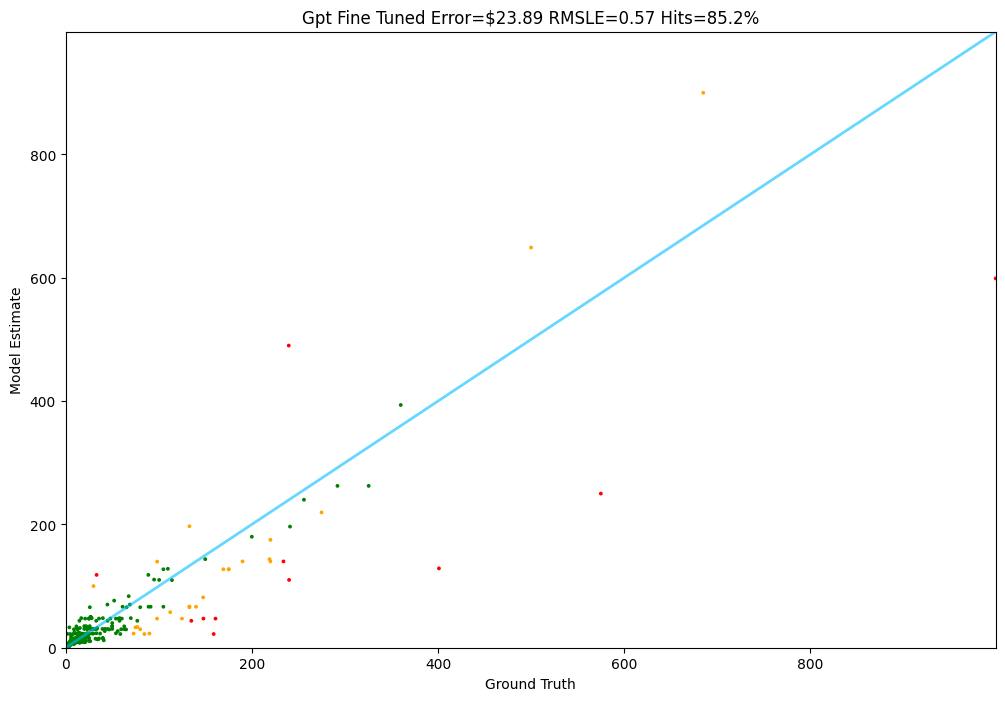

In [36]:
Tester.test(gpt_fine_tuned, test)

### Create a new Fine Tune Job and Check Status

In [37]:
# openai.fine_tuning.jobs.create(
#     training_file=train_file.id,
#     validation_file=validation_file.id,
#     model="gpt-4o-mini-2024-07-18",
#     seed=42,
#     hyperparameters={"n_epochs": 1},  # Reduce to minimize overfitting
#     integrations=[wandb_integration],
#     suffix="pricer-ep1"  # Make suffix meaningful
# )

In [38]:
# jobs = openai.fine_tuning.jobs.list(limit=1).data # Get the first one

In [39]:
# if jobs[0].status not in ["succeeded"]:
#     print(f"\nJob status: {jobs[0].status}, please wait until the job is created....")
# else:
#     print(jobs[0].id, jobs[0].fine_tuned_model)